In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
df = pd.read_csv("data/Housing.csv")

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


#  Data Handling

In [14]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [15]:
df['price_per_area'] = df['price'] / df['area']
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['area_per_room'] = df['area'] / df['bedrooms']

##  - Outliers

C:\Users\harsh\AppData\Local\Temp\ipykernel_4768\4096808670.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price'>

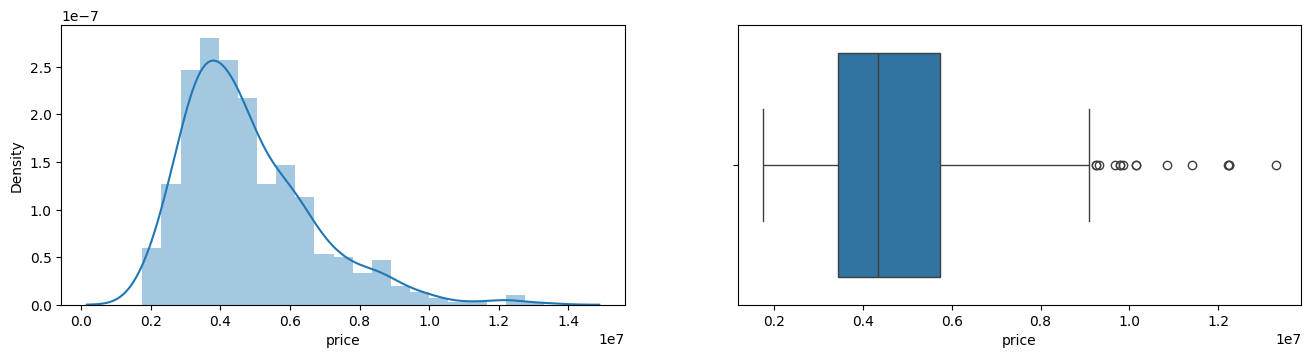

In [16]:

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['price'])

plt.subplot(2,2,2)
sns.boxplot(df['price'], orient="h")


In [17]:
#   perform trimming

qua25 = df["price"].quantile(0.25)
qua75 = df["price"].quantile(0.75)

iqr = qua75 - qua25

upper_limit = qua75 + 1.5 * iqr
lower_limit = qua25 - 1.5 * iqr

print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 9205000.0
Lower limit -35000.0


## outliers

In [18]:
df[df["price"] > upper_limit]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_area,total_rooms,area_per_room
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1792.452830,6,1855.000000
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1367.187500,8,2240.000000
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1229.919679,5,3320.000000
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1628.666667,6,1875.000000
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1537.735849,5,1855.000000
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished,1446.666667,6,2500.000000
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished,1182.983683,7,2145.000000
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished,626.543210,8,3240.000000
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished,1218.518519,5,2025.000000
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished,1704.347826,5,1916.666667


In [19]:
df[df["price"] < lower_limit]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_area,total_rooms,area_per_room


## perform trimming

In [20]:
newDf = df[(df["price"] > lower_limit) & (df["price"] < upper_limit)]

In [21]:
print("Original Shape : ", df.shape)
print("After removing Outliers : ",newDf.shape)

Original Shape :  (545, 16)
After removing Outliers :  (530, 16)


<Axes: xlabel='price'>

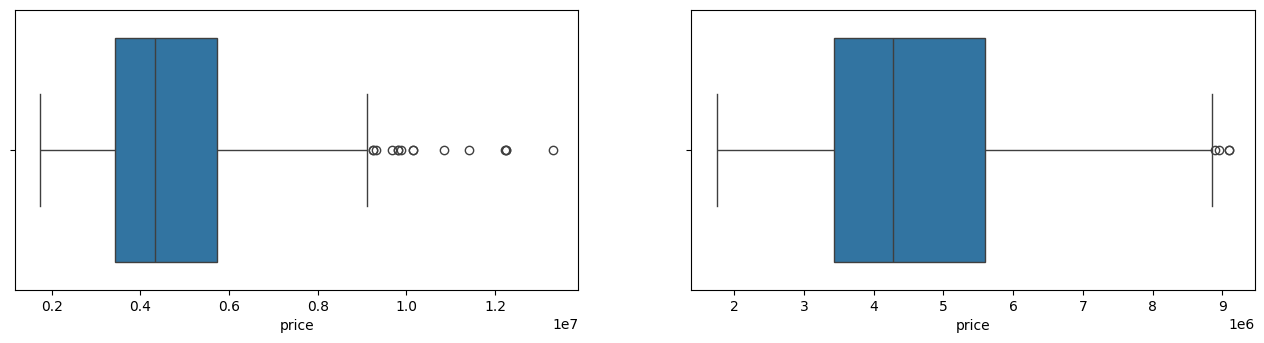

In [22]:

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.boxplot(df['price'], orient="h")

plt.subplot(2,2,2)
sns.boxplot(newDf['price'], orient="h")


## perform capping

In [23]:
new_df_cap = df.copy()

new_df_cap['price'] = np.where(
    new_df_cap['price'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['price'] < lower_limit,
        lower_limit,
        new_df_cap['price']
    )
)

<Axes: xlabel='price'>

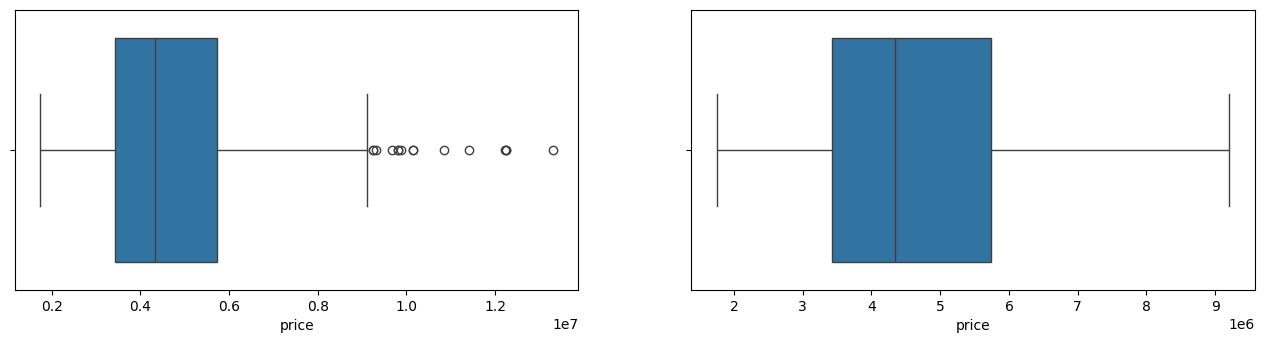

In [24]:

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.boxplot(df['price'], orient="h")

plt.subplot(2,2,2)
sns.boxplot(new_df_cap['price'], orient="h")


In [25]:
newDf["furnishingstatus"].unique()

array(['semi-furnished', 'unfurnished', 'furnished'], dtype=object)

In [26]:
categorial_cols = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"]
numeric_cols = ["area","bedrooms","bathrooms","stories","parking","price_per_area","total_rooms","area_per_room"]

In [27]:
transformers = ColumnTransformer(
    transformers=[
        ("categorial", OneHotEncoder(drop="first", sparse_output=True), categorial_cols),
        ("numeric", StandardScaler(), numeric_cols)
    ]
)

In [28]:
transformers

,transformers,"[('categorial', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [29]:
lr = LinearRegression()

In [30]:
pipe = Pipeline(
steps=[
    ("preproceeser", transformers),
    ("classifier", lr)
]
)

In [31]:
pipe

,steps,"[('preproceeser', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorial', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##  before removing outliers

In [32]:
x = df.drop("price", axis=1)
y = df["price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

print("X_train shape : ",x_train.shape)
print("X_test shape : ",x_test.shape)

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_test)

print("MSE : ", mean_squared_error(y_test, y_pred))
print("MAE : ", mean_absolute_error(y_test, y_pred))
print("R2 Score : ", r2_score(y_test, y_pred))

X_train shape :  (463, 15)
X_test shape :  (82, 15)
MSE :  379409784738.38745
MAE :  416843.11607723736
R2 Score :  0.9100186972224422


##  after removing outliers

In [33]:
x = newDf.drop("price", axis=1)
y = newDf["price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

print("X_train shape : ",x_train.shape)
print("X_test shape : ",x_test.shape)

X_train shape :  (450, 15)
X_test shape :  (80, 15)


In [34]:
pipe.fit(x_train, y_train)

,steps,"[('preproceeser', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorial', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
y_pred = pipe.predict(x_test)

print("MSE : ", mean_squared_error(y_test, y_pred))
print("MAE : ", mean_absolute_error(y_test, y_pred))
print("R2 Score : ", r2_score(y_test, y_pred))

MSE :  467156959611.5412
MAE :  479679.43096124975
R2 Score :  0.8640650652796162


# using capping

In [36]:
x = new_df_cap.drop("price", axis=1)
y = new_df_cap["price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

print("X_train shape : ",x_train.shape)
print("X_test shape : ",x_test.shape)

pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_test)

print("MSE : ", mean_squared_error(y_test, y_pred))
print("MAE : ", mean_absolute_error(y_test, y_pred))
print("R2 Score : ", r2_score(y_test, y_pred))

X_train shape :  (463, 15)
X_test shape :  (82, 15)
MSE :  238368265864.10452
MAE :  382044.179720216
R2 Score :  0.9319308831168386
